In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow Version: 2.21.0


## 1. Load Dataset & Exploratory Data Analysis (EDA)

In [2]:
# Load dataset
df = pd.read_csv('real_estate_dataset.csv')
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (500, 12)


,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


In [3]:
# Summary statistics and missing values check
print("Missing values in dataset:")
print(df.isnull().sum())
print("\nDataset Summary Statistics:")
df.describe()


Missing values in dataset:
ID                    0
Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64

Dataset Summary Statistics:


,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,174.640428,2.958000,1.976000,1.964000,1957.604000,0.536000,0.492000,30.174000,5.164410,10.469641,582209.629529
std,144.481833,74.672102,1.440968,0.820225,0.802491,35.491781,0.499202,0.500437,11.582575,2.853489,5.588197,122273.390345
min,1.000000,51.265396,1.000000,1.000000,1.000000,1900.000000,0.000000,0.000000,10.000000,0.004428,0.062818,276892.470136
25%,125.750000,110.319923,2.000000,1.000000,1.000000,1926.000000,0.000000,0.000000,20.000000,2.760650,6.066754,503080.344140
50%,250.500000,178.290937,3.000000,2.000000,2.000000,1959.000000,1.000000,0.000000,30.000000,5.206518,10.886066,574724.113347
75%,375.250000,239.031220,4.000000,3.000000,3.000000,1988.000000,1.000000,1.000000,41.000000,7.732933,15.072590,665942.301274
max,500.000000,298.241199,5.000000,3.000000,3.000000,2022.000000,1.000000,1.000000,49.000000,9.995439,19.927966,960678.274291


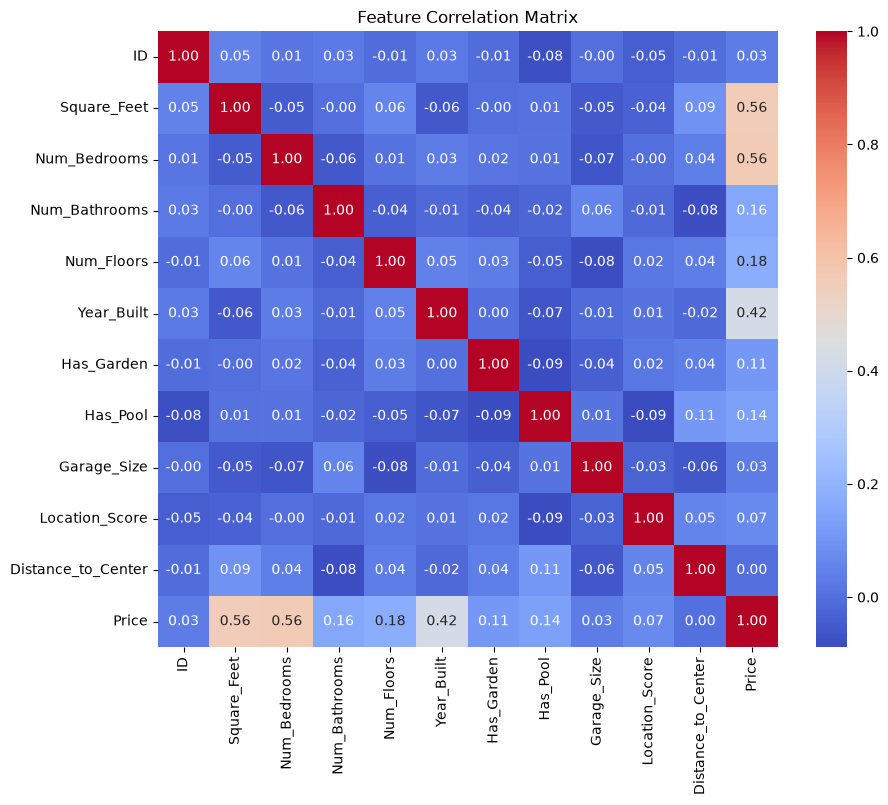

In [4]:
# Feature Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


## 2. Feature Preprocessing & Scaling

In [5]:
# Separate features and target
X = df.drop(columns=['ID', 'Price'])
y = df['Price']

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling using StandardScaler
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

# Target scaling for stable neural network optimization
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

print(f"X_train shape: {X_train_scaled.shape}, y_train shape: {y_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}, y_test shape: {y_test_scaled.shape}")


X_train shape: (400, 10), y_train shape: (400,)
X_test shape: (100, 10), y_test shape: (100,)


## 3. Building the ANN Model Architecture

In [6]:
def build_ann_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.1),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.1),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    
    optimizer = Adam(learning_rate=0.01)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

model = build_ann_model(X_train_scaled.shape[1])
model.summary()


D:\Projects\ANN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 384 (1.50 KB)

## 4. Model Training

In [7]:
early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1)

history = model.fit(
    X_train_scaled, 
    y_train_scaled,
    validation_split=0.15,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/200



 1/22 ━━━━━━━━━━━━━━━━━━━━ 1:20 4s/step - loss: 1.9349 - mae: 1.2410


11/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0331 - mae: 0.7923 


22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.7665 - mae: 0.6793 - val_loss: 0.5017 - val_mae: 0.5946 - learning_rate: 0.0100


Epoch 2/200


...


 1/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0196 - mae: 0.1063


21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0145 - mae: 0.0955 


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0143 - mae: 0.0947 - val_loss: 0.0539 - val_mae: 0.1931 - learning_rate: 6.2500e-04


Epoch 86: early stopping


Restoring model weights from the end of the best epoch: 61.


## 5. Model Evaluation & Accuracy Metrics

In [8]:
# Predict on test set
y_pred_scaled = model.predict(X_test_scaled).flatten()

# Inverse transform predictions back to original USD scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Calculate performance metrics
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
accuracy_percentage = (1 - mape) * 100
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('=' * 50)
print('  ANN Regression Performance Evaluation')
print('=' * 50)
print(f'  R² Score (Coefficient of Determination) : {r2:.4f} ({r2 * 100:.2f}%)')
print(f'  1-MAPE Accuracy                        : {1-mape:.4f} ({accuracy_percentage:.2f}%)')
print(f'  Mean Absolute Error (MAE)              : ${mae:,.2f}')
print(f'  Root Mean Squared Error (RMSE)         : ${rmse:,.2f}')
print('=' * 50)

if r2 > 0.90:
    print('\n[SUCCESS] Target Accuracy (>90% R² Score) achieved!')
else:
    print('\n[WARNING] Accuracy below 90% threshold.')



1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step 


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


  ANN Regression Performance Evaluation
  R² Score (Coefficient of Determination) : 0.9415 (94.15%)
  1-MAPE Accuracy                        : 0.9523 (95.23%)
  Mean Absolute Error (MAE)              : $23,422.33
  Root Mean Squared Error (RMSE)         : $29,668.05

[SUCCESS] Target Accuracy (>90% R² Score) achieved!


## 6. Visualization & Error Analysis

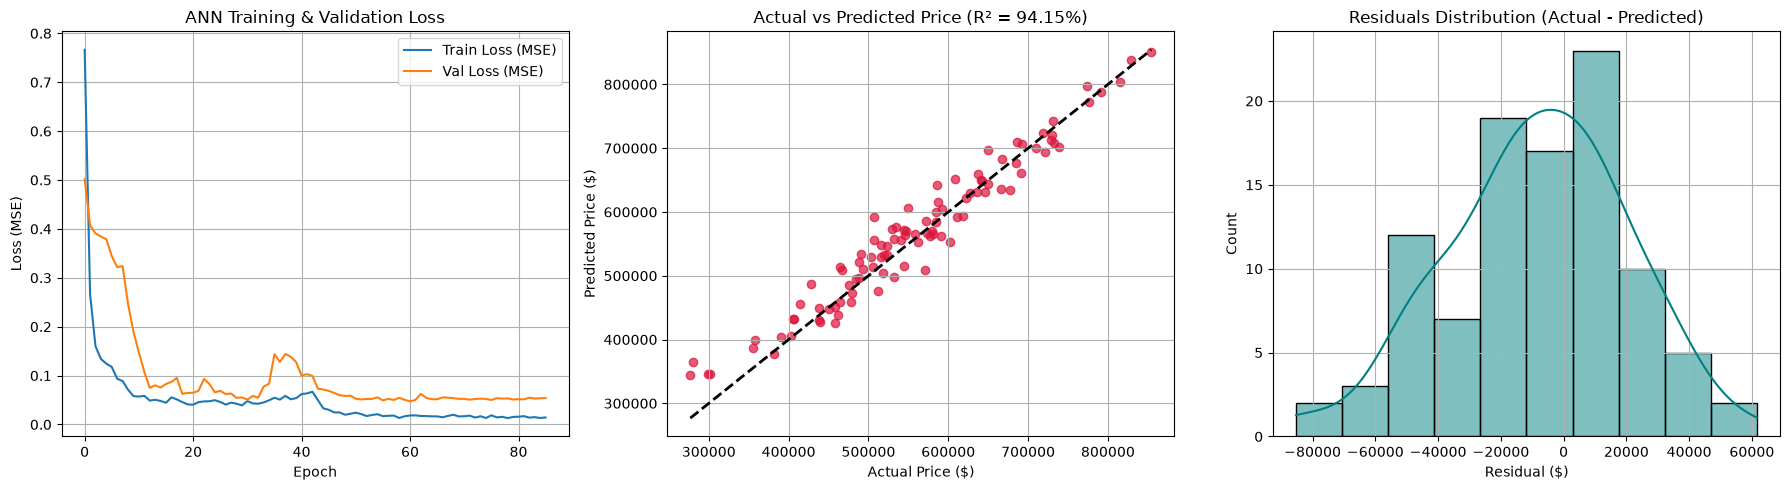

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Training & Validation Loss
axes[0].plot(history.history['loss'], label='Train Loss (MSE)')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)')
axes[0].set_title('ANN Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Actual vs Predicted Prices
axes[1].scatter(y_test, y_pred, alpha=0.7, color='crimson')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1].set_title(f'Actual vs Predicted Price (R² = {r2*100:.2f}%)')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].grid(True)

# Plot 3: Residuals Distribution
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[2], color='teal')
axes[2].set_title('Residuals Distribution (Actual - Predicted)')
axes[2].set_xlabel('Residual ($)')
axes[2].grid(True)

plt.tight_layout()
plt.show()
